Read files 

In [113]:

import eyed3

# Load the MP3 file
audio_path = 'sample-000013.mp3'
audio_file = eyed3.load(audio_path)

# Get the sampling rate
sampling_rate = audio_file.info.sample_freq
print(f"Sampling Rate: {sampling_rate} Hz")
sr= 48000

Sampling Rate: 48000 Hz


In [114]:
from IPython.display import Audio
import librosa
# Load an MP3 file
sr=16000
audio_path = 'sample-000000.mp3'

audio, sr = librosa.load(audio_path, sr=sr)  # sr is the sample rate (set to 16kHz)
first_3_seconds = audio[:sr*3] 
print(f"Audio shape: {first_3_seconds.shape}, Sample rate: {sr}")
Audio(first_3_seconds, rate=sr)

Audio shape: (48000,), Sample rate: 16000


In [115]:
import numpy as np
sr=48000
audio_paths=['sample-000000.mp3','sample-000002.mp3','sample-000013.mp3']
def read_sources(audio_paths=audio_paths, sr=sr):
    sources= []
    for audio_path in audio_paths:
        audio, sr = librosa.load(audio_path, sr=sr)  # sr is the sample rate (set to 16kHz)
        first_3_seconds = audio[:sr*3] 
        sources.append(first_3_seconds)
        
    sources=np.array(sources)
    return sources

sources= read_sources(audio_paths)

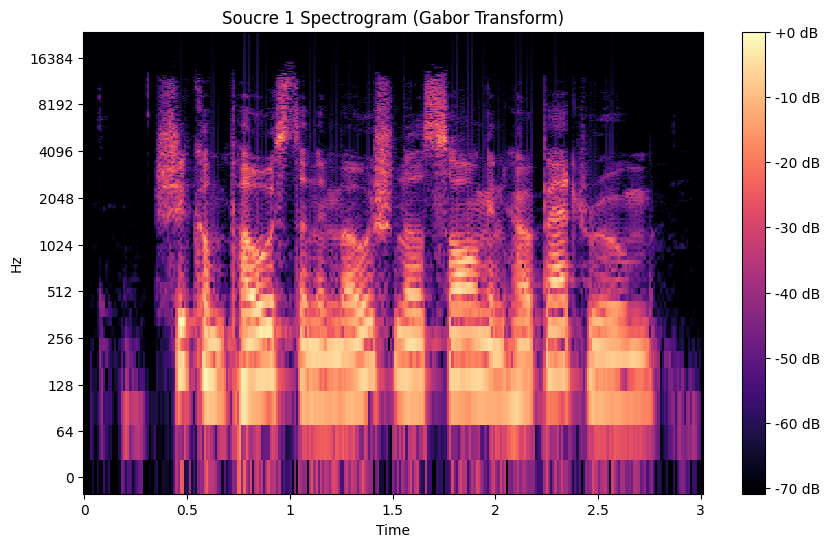

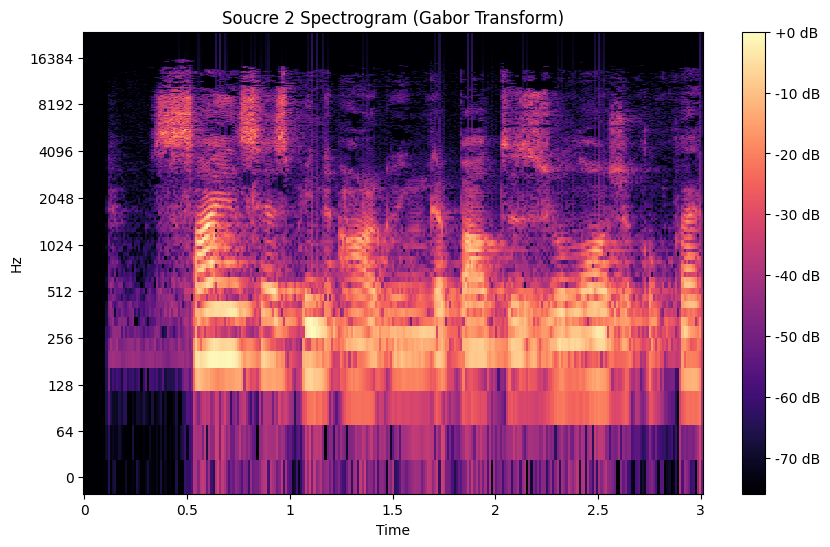

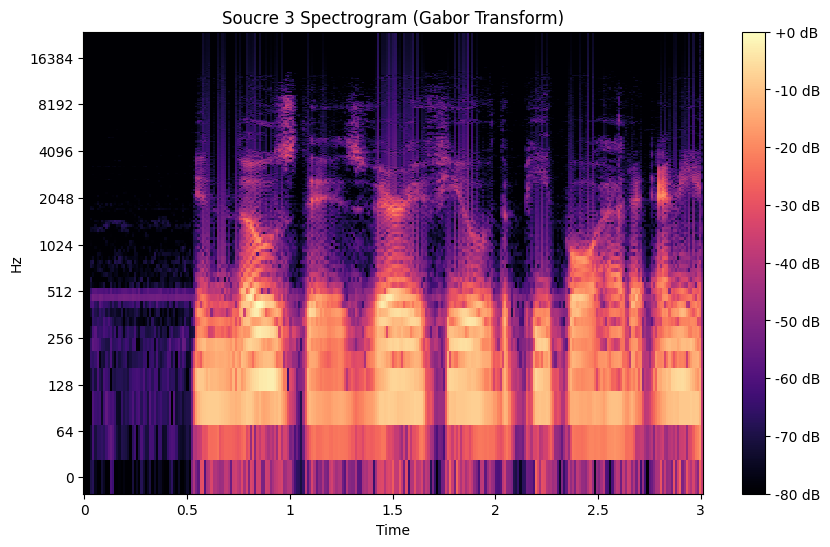

In [116]:
import scipy.signal as signal
import matplotlib.pyplot as plt 
n_fft_0=1024
hop_length_0= 512

def compute_gabor_transform_with_f_t(signals, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian'):
    gabor_transforms = []
    for signal_data in signals:
        if window_type == 'gaussian':
            window = signal.windows.gaussian(window_size, std=window_size / 4)
        else:
            window = signal.windows.get_window(window_type, window_size)
        f, t, Zxx = signal.stft(signal_data, nperseg=window_size, noverlap=hop_length, window=window)
        
        gabor_transforms.append(Zxx)
    return np.array(gabor_transforms),f,t
def plot_spectrogram(stft_matrix, sr=sr, title="Spectrogram"):
    plt.figure(figsize=(10, 6))
    
    librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max), sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.show()
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
for i, stft in enumerate(sources_stft, 1):
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")

In [117]:
A=np.random.normal(0,1,(5,2,3))
def Aire(lorenz):
    """Computes the area A(x) under the Lorenz curve using the formula:
        A(x) = 1 / (2N) * sum(L(n-1/N) + L(n/N)) for all n
    """
    N = len(lorenz) 
    area = 0
    for n in range(1, N+1):
        area += (lorenz[n-1] + lorenz[n-1 if n == N else n]) / N
    return 0.5 * area
def gini_index(A=A, matrix = True  ): 
    if  matrix : 
        A= A.reshape(-1)
    sorted_signal = np.sort(np.abs(A))
    cumulative_sum = np.cumsum(sorted_signal) 
    lorenz = cumulative_sum / cumulative_sum[-1]
    area = Aire(lorenz)
    gini = 1 - 2 * area
    return gini

In [118]:
for i in range( len(audio_paths)):  
    print(f'the gini index of the stft of the {i}th signal is ' , gini_index(sources_stft[0], matrix= True))

the gini index of the stft of the 0th signal is  0.926782240661137
the gini index of the stft of the 1th signal is  0.926782240661137
the gini index of the stft of the 2th signal is  0.926782240661137
